In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
ds = xr.open_dataset("../data/CV_FTLE_2025.zarr")
ds

/home/b/b384140/.conda/envs/parcels/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


<xarray.Dataset> Size: 135MB
Dimensions:  (time: 73, plon: 544, plat: 424)
Coordinates:
    day      <U4 16B ...
  * plat     (plat) float64 3kB 13.0 13.02 13.03 13.05 ... 19.97 19.98 20.0
  * plon     (plon) float64 4kB -29.0 -28.98 -28.97 ... -20.03 -20.02 -20.0
  * time     (time) datetime64[ns] 584B 2025-01-01 2025-01-06 ... 2025-12-27
Data variables:
    FTLE     (time, plon, plat) float64 135MB ...

In [3]:
ds_heatmap_2025 = xr.open_dataset("../data/SV_heatmap_2025_binned.zarr", engine="zarr")
ds_heatmap_2025

<xarray.Dataset> Size: 12GB
Dimensions:            (release_date: 73, obs: 240, lon: 346, lat: 238)
Coordinates:
  * lat                (lat) float64 2kB 15.42 15.43 15.44 ... 17.77 17.78 17.79
  * lon                (lon) float64 3kB -27.13 -27.12 -27.11 ... -23.69 -23.68
  * obs                (obs) int32 960B 0 1 2 3 4 5 ... 234 235 236 237 238 239
  * release_date       (release_date) datetime64[ns] 584B 2025-01-01 ... 2025...
Data variables:
    histogram_lon_lat  (release_date, obs, lon, lat) int64 12GB ...

In [4]:
# confirm the two date axes actually match
assert (ds_heatmap_2025.release_date.values == ds.time.values).all(), "dates don't align — check order/values"

dates = ds_heatmap_2025.release_date.values
n_dates = len(dates)

In [5]:
# Option A: where particles ended up (last obs)
dispersal = ds_heatmap_2025.histogram_lon_lat.isel(obs=-1)

# Option B: full footprint over the trajectory (all obs summed)
# dispersal = ds_heatmap_2025.histogram_lon_lat.sum(dim="obs")

dispersal_log = np.log10(dispersal + 1)

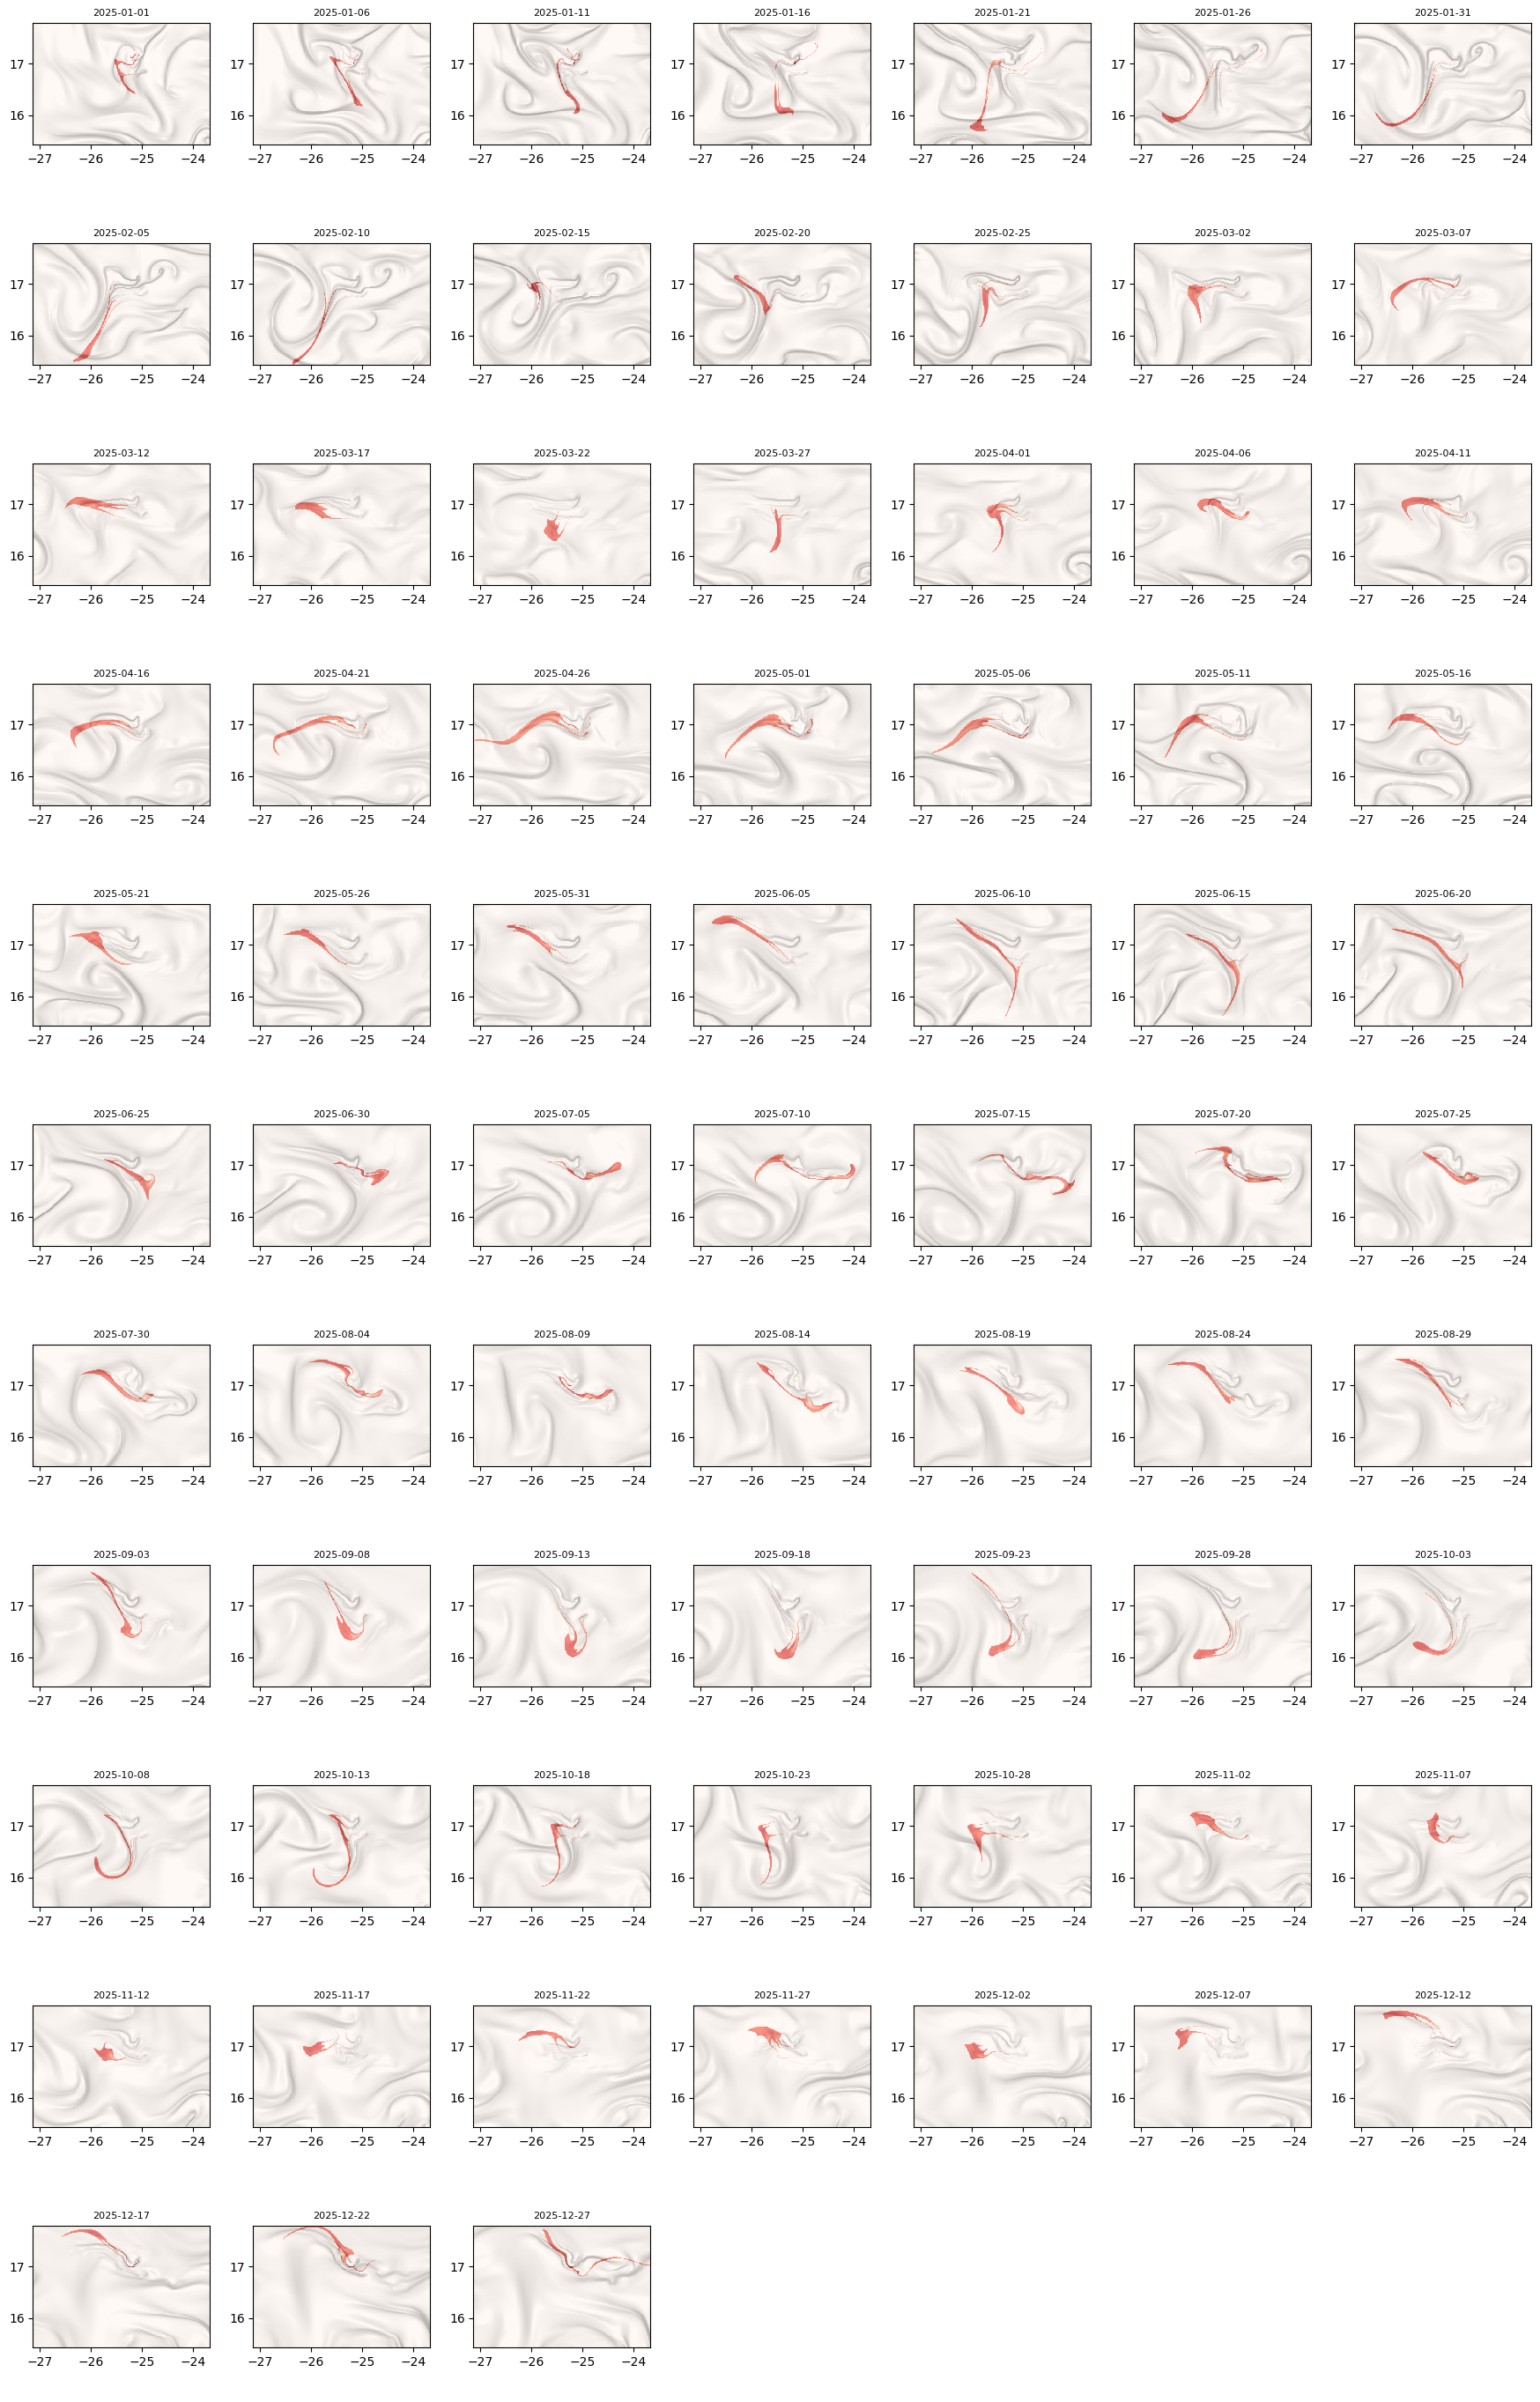

In [7]:
col_wrap = 7
n_rows = int(np.ceil(n_dates / col_wrap))

fig, axes = plt.subplots(
    n_rows, col_wrap,
    figsize=(col_wrap * 2.5, n_rows * 2.5),
    constrained_layout=True,
)
axes_flat = axes.flat

# shared color scales across all panels, so dates are visually comparable
ftle_vmax = float(ds.FTLE.max())
disp_vmax = float(dispersal_log.max())

for i, d in enumerate(dates):
    ax = axes_flat[i]

    ftle_slice = ds.FTLE.sel(time=d)
    disp_slice = dispersal_log.sel(release_date=d)

    # background shading: FTLE
    ftle_slice.plot.pcolormesh(
        x="plon", y="plat", ax=ax,
        cmap="Greys", vmin=0, vmax=ftle_vmax,
        add_colorbar=False,
    )

    # overlay: particle dispersal
    disp_slice.plot.pcolormesh(
        x="lon", y="lat", ax=ax,
        cmap="Reds", alpha=0.6, vmin=0, vmax=disp_vmax,
        add_colorbar=False,
    )

    ax.set_aspect("equal")
    ax.set_title(np.datetime_as_string(d, unit="D"), fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")

# turn off any unused trailing axes (if n_dates doesn't fill the grid exactly)
for j in range(n_dates, len(axes_flat)):
    axes_flat[j].axis("off")

plt.show()